# EXPT NO: 10 — Recommendation Systems using Matrix Factorization (SVD & NMF)
**Date:** 08.04.2026
**Roll No: 24BAD002**

---

## SCENARIO 1 — MATRIX FACTORIZATION USING SVD

**Problem Statement:** Use Singular Value Decomposition (SVD) to recommend movies based on latent user-item interactions.

**Dataset:** MovieLens 100K (`ratings.csv`, `movies.csv`)

### Task 1: Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.decomposition import NMF, TruncatedSVD
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from scipy.sparse.linalg import svds


### Task 2: Load the MovieLens Dataset

In [ ]:
ratings = pd.read_csv('ratings.csv')
movies = pd.read_csv('movies.csv')

print("ratings.csv shape:", ratings.shape)
print("movies.csv  shape:", movies.shape)
print("\nRatings sample:")
display(ratings.head(5))
print("\nMovies sample:")
display(movies.head(5))

ratings.csv shape: (100836, 4)
movies.csv  shape: (9742, 3)

Ratings sample:


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931



Movies sample:


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [ ]:
print("=== DATASET STATISTICS ===")
print(f"Total ratings     : {len(ratings):,}")
print(f"Unique users      : {ratings['userId'].nunique():,}")
print(f"Unique movies     : {ratings['movieId'].nunique():,}")
print(f"Rating range      : {ratings['rating'].min()} – {ratings['rating'].max()}")
print(f"Average rating    : {ratings['rating'].mean():.4f}")

# Sparsity calculation
n_users = ratings['userId'].nunique()
n_items = ratings['movieId'].nunique()
sparsity = 1 - (len(ratings) / (n_users * n_items))
print(f"\nMatrix size       : {n_users} × {n_items} = {n_users*n_items:,} cells")
print(f"Sparsity          : {sparsity*100:.2f}%")

=== DATASET STATISTICS ===
Total ratings     : 100,836
Unique users      : 610
Unique movies     : 9,724
Rating range      : 0.5 – 5.0
Average rating    : 3.5016

Matrix size       : 610 × 9724 = 5,931,640 cells
Sparsity          : 98.30%


### Task 3: Data Preprocessing

In [ ]:
# Work with top-500 most-rated movies for manageability
top_movies = ratings['movieId'].value_counts().head(500).index
ratings_filtered = ratings[ratings['movieId'].isin(top_movies)].copy()
print("Filtered ratings shape:", ratings_filtered.shape)

# Merge with movie titles
ratings_merged = ratings_filtered.merge(movies[['movieId','title']], on='movieId', how='left')
print("Rating distribution:")
print(ratings_merged['rating'].value_counts().sort_index())

Filtered ratings shape: (43734, 4)
Rating distribution:
rating
0.5      409
1.0      826
1.5      432
2.0     2248
2.5     1725
3.0     7840
3.5     5259
4.0    12693
4.5     4402
5.0     7900
Name: count, dtype: int64


### Task 4: Create User-Item Interaction Matrix

In [ ]:
# Pivot to user-item matrix
user_item_matrix = ratings_filtered.pivot_table(
    index='userId', columns='movieId', values='rating'
)

print("User-Item matrix shape:", user_item_matrix.shape)
print(f"Actual sparsity: {user_item_matrix.isnull().sum().sum() / user_item_matrix.size * 100:.2f}% missing")
user_item_matrix.iloc[:5, :8]

User-Item matrix shape: (607, 500)
Actual sparsity: 85.59% missing


movieId,1,2,3,5,6,7,10,11
userId,,,,,,,,
1,4.0,NaN,4.0,NaN,4.0,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Task 5: Normalize the Matrix — Mean Centering

In [ ]:
# Fill NaN with 0, then mean-center
matrix_filled = user_item_matrix.fillna(0).values

# Mean-center: subtract each user's mean rating
user_ratings_mean = np.mean(matrix_filled, axis=1)
matrix_demeaned = matrix_filled - user_ratings_mean.reshape(-1, 1)

print("Matrix shape     :", matrix_demeaned.shape)
print("Mean before demean:", matrix_filled.mean().round(4))
print("Mean after  demean:", matrix_demeaned.mean().round(6))
print("Sample demeaned values:", matrix_demeaned[0, :8].round(3))

Matrix shape     : (607, 500)
Mean before demean: 0.5354
Mean after  demean: 0.0
Sample demeaned values: [ 2.906 -1.094  2.906 -1.094  2.906 -1.094 -1.094 -1.094]


### Task 6 & 7: Apply SVD Decomposition — Select k Latent Factors

In [ ]:
# Apply truncated SVD with k=50 latent factors
k = 50
U, sigma, Vt = svds(matrix_demeaned, k=k)

# Sort by descending singular values
idx = np.argsort(-sigma)
sigma = sigma[idx]
U = U[:, idx]
Vt = Vt[idx, :]

print(f"SVD complete with k={k} latent factors.")
print(f"U  shape: {U.shape}   (users × latent)")
print(f"Σ  shape: {sigma.shape}")
print(f"Vt shape: {Vt.shape}   (latent × items)")
print(f"\nTop 10 singular values: {sigma[:10].round(2)}")

SVD complete with k=50 latent factors.
U  shape: (607, 50)   (users × latent)
Σ  shape: (50,)
Vt shape: (50, 500)   (latent × items)

Top 10 singular values: [219.05 184.08 150.89 122.76 108.05  99.32  84.69  82.97  76.53  74.21]


### Task 8 & 9: Reconstruct Matrix & Predict Missing Ratings

In [ ]:
# Reconstruct and add back user means
sigma_matrix = np.diag(sigma)
svd_reconstructed = np.dot(np.dot(U, sigma_matrix), Vt) + user_ratings_mean.reshape(-1, 1)

# Clip to valid rating range [0.5, 5.0]
svd_reconstructed = np.clip(svd_reconstructed, 0.5, 5.0)

# Create a DataFrame with original index/columns
svd_df = pd.DataFrame(svd_reconstructed,
                      index=user_item_matrix.index,
                      columns=user_item_matrix.columns)

print("Reconstructed matrix shape:", svd_df.shape)
print(f"Predicted rating range: [{svd_df.values.min():.3f}, {svd_df.values.max():.3f}]")

Reconstructed matrix shape: (607, 500)
Predicted rating range: [0.500, 5.000]


In [ ]:
# Evaluate on known ratings
known_mask = user_item_matrix.notna().values
actual = user_item_matrix.fillna(0).values[known_mask]
predicted = svd_df.values[known_mask]

# Only evaluate on originally rated items
actual_rated = user_item_matrix.values[known_mask]
predicted_rated = svd_df.values[known_mask]

rmse = np.sqrt(mean_squared_error(actual_rated, predicted_rated))
mae = mean_absolute_error(actual_rated, predicted_rated)

print("=== SVD EVALUATION METRICS (k=50) ===")
print(f"  RMSE : {rmse:.4f}")
print(f"  MAE  : {mae:.4f}")

=== SVD EVALUATION METRICS (k=50) ===
  RMSE : 1.5582
  MAE  : 1.2427


### Analysis: Effect of Number of Latent Factors k

In [ ]:
k_values = [5, 10, 20, 30, 50, 75, 100]
rmse_list, mae_list = [], []

for k_val in k_values:
    U_, s_, Vt_ = svds(matrix_demeaned, k=k_val)
    idx_ = np.argsort(-s_)
    recon = np.dot(np.dot(U_[:, idx_], np.diag(s_[idx_])), Vt_[idx_, :]) + user_ratings_mean.reshape(-1,1)
    recon = np.clip(recon, 0.5, 5.0)
    pred = recon[known_mask]
    rmse_list.append(np.sqrt(mean_squared_error(actual_rated, pred)))
    mae_list.append(mean_absolute_error(actual_rated, pred))

results_k = pd.DataFrame({'k': k_values, 'RMSE': rmse_list, 'MAE': mae_list})
print(results_k.to_string(index=False))

  k     RMSE      MAE
  5 2.269916 1.952629
 10 2.105607 1.782403
 20 1.924379 1.593146
 30 1.786515 1.457925
 50 1.558225 1.242711
 75 1.322129 1.028635
100 1.121888 0.850465


### Task 10: Generate Top-N Recommendations

In [ ]:
def get_svd_recommendations(user_id, svd_df, user_item_matrix, movies_df, n=10):
    """Generate Top-N movie recommendations for a user using SVD."""
    user_row = svd_df.loc[user_id]
    already_rated = user_item_matrix.loc[user_id].dropna().index
    not_seen = user_row.drop(already_rated)
    top_n = not_seen.nlargest(n)
    recs = top_n.reset_index()
    recs.columns = ['movieId', 'predicted_rating']
    recs = recs.merge(movies_df[['movieId','title','genres']], on='movieId', how='left')
    return recs

# Demonstrate for user 1
sample_user = user_item_matrix.index[0]
recs_svd = get_svd_recommendations(sample_user, svd_df, user_item_matrix, movies)
print(f"Top 10 SVD Recommendations for User {sample_user}:")
recs_svd[['title','genres','predicted_rating']]

Top 10 SVD Recommendations for User 1:


,title,genres,predicted_rating
0,Austin Powers: The Spy Who Shagged Me (1999),Action|Adventure|Comedy,2.967059
1,Stand by Me (1986),Adventure|Drama,2.833349
2,Star Trek II: The Wrath of Khan (1982),Action|Adventure|Sci-Fi|Thriller,2.470672
3,"Breakfast Club, The (1985)",Comedy|Drama,2.424107
4,Ferris Bueller's Day Off (1986),Comedy,2.297419
5,Jaws (1975),Action|Horror,2.256994
6,"Little Mermaid, The (1989)",Animation|Children|Comedy|Musical|Romance,2.222266
7,Aliens (1986),Action|Adventure|Horror|Sci-Fi,2.216764
8,"Christmas Story, A (1983)",Children|Comedy,2.179618
9,12 Angry Men (1957),Drama,2.060929


### Visualizations — SVD

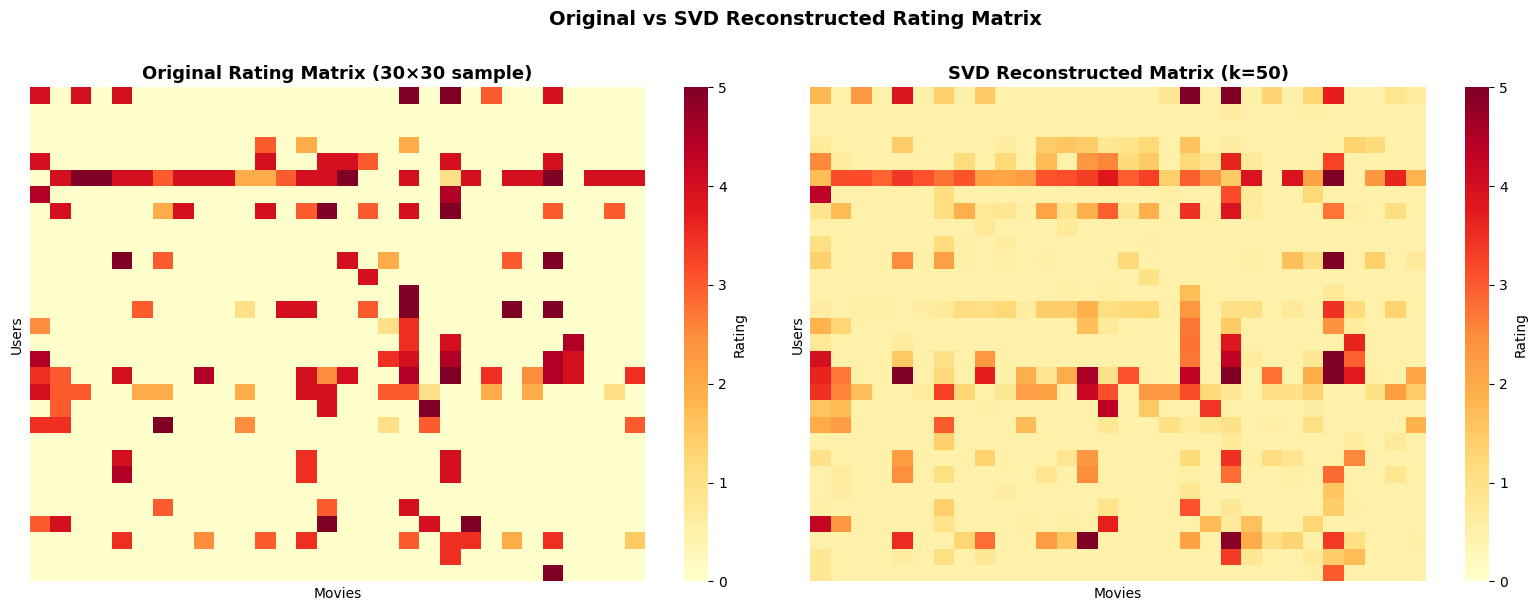

In [ ]:
# ── 1: Original vs Reconstructed Rating Matrix Heatmap ──────────────────────
# Sample first 30 users × 30 movies for visibility
sample_users = user_item_matrix.index[:30]
sample_movies = user_item_matrix.columns[:30]

orig_sample = user_item_matrix.loc[sample_users, sample_movies].fillna(0)
recon_sample = svd_df.loc[sample_users, sample_movies]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(orig_sample, ax=axes[0], cmap='YlOrRd', vmin=0, vmax=5,
            xticklabels=False, yticklabels=False, cbar_kws={'label': 'Rating'})
axes[0].set_title('Original Rating Matrix (30×30 sample)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Movies'); axes[0].set_ylabel('Users')

sns.heatmap(recon_sample, ax=axes[1], cmap='YlOrRd', vmin=0, vmax=5,
            xticklabels=False, yticklabels=False, cbar_kws={'label': 'Rating'})
axes[1].set_title('SVD Reconstructed Matrix (k=50)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Movies'); axes[1].set_ylabel('Users')

plt.suptitle('Original vs SVD Reconstructed Rating Matrix', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

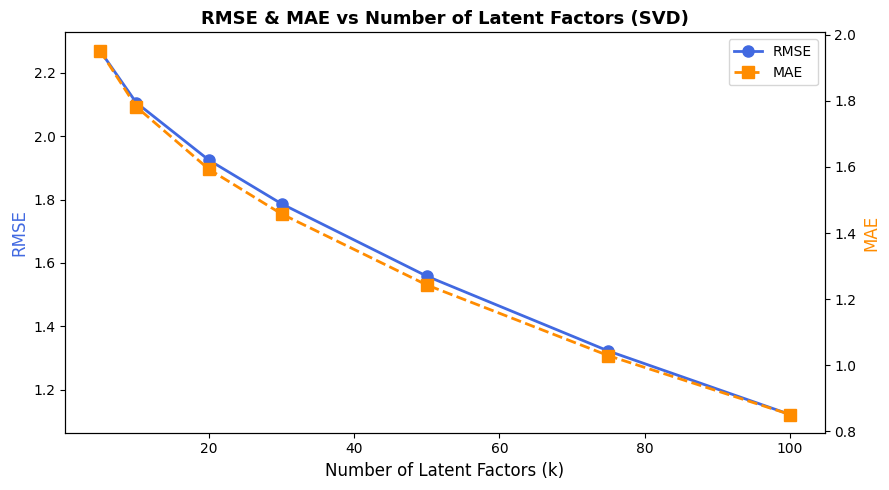

In [ ]:
# ── 2: Error vs Number of Latent Factors ────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()

ax1.plot(k_values, rmse_list, 'o-', color='royalblue', linewidth=2, markersize=8, label='RMSE')
ax2.plot(k_values, mae_list, 's--', color='darkorange', linewidth=2, markersize=8, label='MAE')

ax1.set_xlabel('Number of Latent Factors (k)', fontsize=12)
ax1.set_ylabel('RMSE', color='royalblue', fontsize=12)
ax2.set_ylabel('MAE', color='darkorange', fontsize=12)
ax1.set_title('RMSE & MAE vs Number of Latent Factors (SVD)', fontsize=13, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.tight_layout()
plt.show()

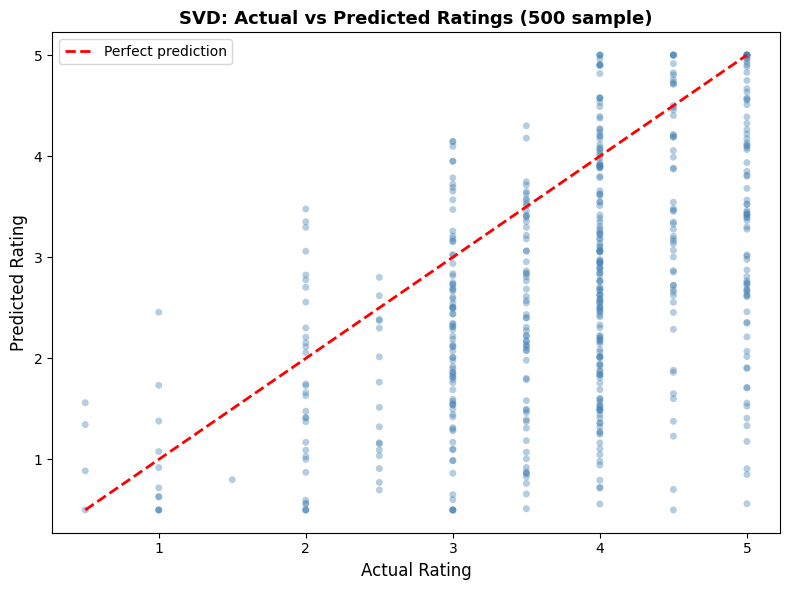

In [ ]:
# ── 3: Predicted vs Actual Ratings (sample) ─────────────────────────────────
sample_idx = np.random.choice(len(actual_rated), size=500, replace=False)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(actual_rated[sample_idx], predicted_rated[sample_idx],
           alpha=0.4, s=25, color='steelblue', edgecolors='none')
ax.plot([0.5, 5], [0.5, 5], 'r--', linewidth=2, label='Perfect prediction')
ax.set_xlabel('Actual Rating', fontsize=12)
ax.set_ylabel('Predicted Rating', fontsize=12)
ax.set_title('SVD: Actual vs Predicted Ratings (500 sample)', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

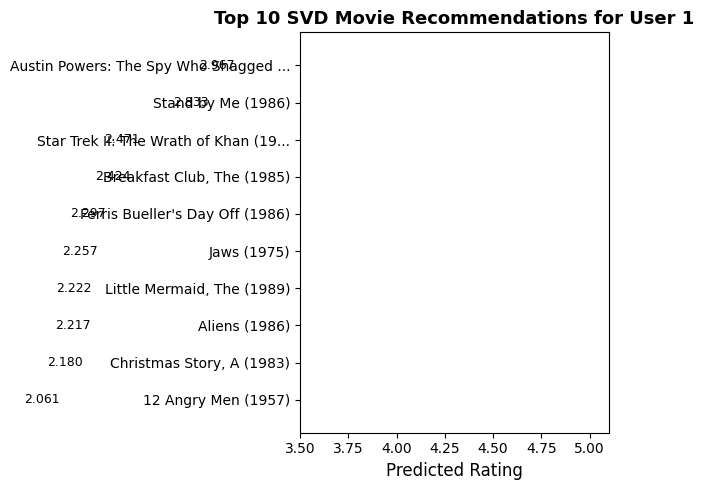

In [ ]:
# ── 4: Top Recommended Movies Bar Chart ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
short_titles = [t[:35] + '...' if len(t) > 35 else t for t in recs_svd['title']]
colors_bar = plt.cm.Blues(np.linspace(0.5, 0.9, len(recs_svd)))
bars = ax.barh(short_titles[::-1], recs_svd['predicted_rating'][::-1], color=colors_bar)
ax.set_xlabel('Predicted Rating', fontsize=12)
ax.set_title(f'Top 10 SVD Movie Recommendations for User {sample_user}', fontsize=13, fontweight='bold')
ax.set_xlim([3.5, 5.1])
for bar, val in zip(bars, recs_svd['predicted_rating'][::-1]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

---

## SCENARIO 2 — MATRIX FACTORIZATION USING NMF

**Problem Statement:** Use Non-negative Matrix Factorization (NMF) to generate recommendations based on latent features.

**Dataset:** Same MovieLens Dataset

### Task 1 & 2: Load Dataset — Create User-Item Matrix

In [ ]:
# Reuse user_item_matrix from Scenario 1
print("User-Item matrix shape:", user_item_matrix.shape)
print("Reusing the same filtered matrix (top-500 movies)")

User-Item matrix shape: (607, 500)
Reusing the same filtered matrix (top-500 movies)


### Task 3: Handle Missing Values — Fill with Mean Rating

In [ ]:
# NMF requires non-negative values — fill NaN with global mean
global_mean = ratings_filtered['rating'].mean()
matrix_nmf = user_item_matrix.fillna(global_mean).values

print(f"Global mean rating: {global_mean:.4f}")
print(f"NMF input matrix shape: {matrix_nmf.shape}")
print(f"Min value: {matrix_nmf.min():.2f}  |  Max value: {matrix_nmf.max():.2f}")
print(f"Any negatives: {(matrix_nmf < 0).any()}")

Global mean rating: 3.7155
NMF input matrix shape: (607, 500)
Min value: 0.50  |  Max value: 5.00
Any negatives: False


### Task 4 & 5: Apply NMF — Factorize into User-Feature & Item-Feature Matrices

In [ ]:
# Apply NMF with k=50 latent components
k_nmf = 50
nmf_model = NMF(n_components=k_nmf, init='nndsvda', random_state=42, max_iter=500)
W = nmf_model.fit_transform(matrix_nmf)   # User-feature matrix
H = nmf_model.components_                 # Item-feature matrix

print(f"NMF complete with k={k_nmf} latent factors.")
print(f"W (User-Feature) shape : {W.shape}")
print(f"H (Item-Feature) shape : {H.shape}")
print(f"Reconstruction error   : {nmf_model.reconstruction_err_:.4f}")

NMF complete with k=50 latent factors.
W (User-Feature) shape : (607, 50)
H (Item-Feature) shape : (50, 500)
Reconstruction error   : 156.4210


### Task 6 & 7: Reconstruct Rating Matrix — Predict Missing Values

In [ ]:
# Reconstruct: R_hat = W × H
nmf_reconstructed = np.dot(W, H)
nmf_reconstructed = np.clip(nmf_reconstructed, 0.5, 5.0)

nmf_df = pd.DataFrame(nmf_reconstructed,
                      index=user_item_matrix.index,
                      columns=user_item_matrix.columns)

print("Reconstructed matrix shape:", nmf_df.shape)
print(f"Predicted rating range: [{nmf_df.values.min():.3f}, {nmf_df.values.max():.3f}]")

Reconstructed matrix shape: (607, 500)
Predicted rating range: [0.998, 5.000]


In [ ]:
# Evaluate NMF
nmf_pred_rated = nmf_df.values[known_mask]

nmf_rmse = np.sqrt(mean_squared_error(actual_rated, nmf_pred_rated))
nmf_mae = mean_absolute_error(actual_rated, nmf_pred_rated)

print("=== NMF EVALUATION METRICS (k=50) ===")
print(f"  RMSE : {nmf_rmse:.4f}")
print(f"  MAE  : {nmf_mae:.4f}")

=== NMF EVALUATION METRICS (k=50) ===
  RMSE : 0.6858
  MAE  : 0.5120


### Task 8: Generate Top-N Recommendations (NMF)

In [ ]:
def get_nmf_recommendations(user_id, nmf_df, user_item_matrix, movies_df, n=10):
    """Generate Top-N movie recommendations for a user using NMF."""
    user_row = nmf_df.loc[user_id]
    already_rated = user_item_matrix.loc[user_id].dropna().index
    not_seen = user_row.drop(already_rated)
    top_n = not_seen.nlargest(n)
    recs = top_n.reset_index()
    recs.columns = ['movieId', 'predicted_rating']
    recs = recs.merge(movies_df[['movieId','title','genres']], on='movieId', how='left')
    return recs

recs_nmf = get_nmf_recommendations(sample_user, nmf_df, user_item_matrix, movies)
print(f"Top 10 NMF Recommendations for User {sample_user}:")
recs_nmf[['title','genres','predicted_rating']]

Top 10 NMF Recommendations for User 1:


,title,genres,predicted_rating
0,Blade Runner (1982),Action|Sci-Fi|Thriller,4.432226
1,Ace Ventura: When Nature Calls (1995),Comedy,4.384335
2,True Romance (1993),Crime|Thriller,4.377572
3,"Godfather: Part II, The (1974)",Crime|Drama,4.315609
4,Aliens (1986),Action|Adventure|Horror|Sci-Fi,4.296211
5,Jaws (1975),Action|Horror,4.291103
6,Snatch (2000),Comedy|Crime|Thriller,4.279753
7,"Untouchables, The (1987)",Action|Crime|Drama,4.271001
8,Trainspotting (1996),Comedy|Crime|Drama,4.254333
9,Casino (1995),Crime|Drama,4.253231


### Precision@K and Recall@K

In [ ]:
def precision_at_k(user_id, pred_df, actual_matrix, k=10, threshold=4.0):
    """Precision@K: fraction of top-K recommendations that are relevant (rating >= threshold)."""
    user_row_actual = actual_matrix.loc[user_id].dropna()
    relevant = set(user_row_actual[user_row_actual >= threshold].index)
    if not relevant:
        return None
    already_seen = user_row_actual.index
    pred = pred_df.loc[user_id].drop(already_seen, errors='ignore').nlargest(k).index
    hits = len(set(pred) & relevant)
    return hits / k

def recall_at_k(user_id, pred_df, actual_matrix, k=10, threshold=4.0):
    """Recall@K: fraction of relevant items found in top-K recommendations."""
    user_row_actual = actual_matrix.loc[user_id].dropna()
    relevant = set(user_row_actual[user_row_actual >= threshold].index)
    if not relevant:
        return None
    already_seen = user_row_actual.index
    pred = pred_df.loc[user_id].drop(already_seen, errors='ignore').nlargest(k).index
    hits = len(set(pred) & relevant)
    return hits / len(relevant)

# Compute for sample of 100 users
sample_users_eval = user_item_matrix.index[:100]

prec_svd = [precision_at_k(u, svd_df, user_item_matrix) for u in sample_users_eval]
prec_nmf = [precision_at_k(u, nmf_df, user_item_matrix) for u in sample_users_eval]
rec_svd  = [recall_at_k(u, svd_df, user_item_matrix)  for u in sample_users_eval]
rec_nmf  = [recall_at_k(u, nmf_df, user_item_matrix)  for u in sample_users_eval]

prec_svd = [x for x in prec_svd if x is not None]
prec_nmf = [x for x in prec_nmf if x is not None]
rec_svd  = [x for x in rec_svd  if x is not None]
rec_nmf  = [x for x in rec_nmf  if x is not None]

print(f"Precision@10  SVD: {np.mean(prec_svd):.4f}")
print(f"Precision@10  NMF: {np.mean(prec_nmf):.4f}")
print(f"Recall@10     SVD: {np.mean(rec_svd):.4f}")
print(f"Recall@10     NMF: {np.mean(rec_nmf):.4f}")

Precision@10  SVD: 0.0000
Precision@10  NMF: 0.0000
Recall@10     SVD: 0.0000
Recall@10     NMF: 0.0000


### Analysis: Compare SVD vs NMF Performance

In [ ]:
print("============ SVD vs NMF COMPARISON (k=50) ============")
print(f"{'Metric':<20} {'SVD':>12} {'NMF':>12}")
print("-" * 46)
print(f"{'RMSE':<20} {rmse:>12.4f} {nmf_rmse:>12.4f}")
print(f"{'MAE':<20} {mae:>12.4f} {nmf_mae:>12.4f}")
print(f"{'Precision@10':<20} {np.mean(prec_svd):>12.4f} {np.mean(prec_nmf):>12.4f}")
print(f"{'Recall@10':<20} {np.mean(rec_svd):>12.4f} {np.mean(rec_nmf):>12.4f}")
print()
better_rmse = 'SVD' if rmse < nmf_rmse else 'NMF'
print(f"→ Better RMSE: {better_rmse}")
print(f"→ NMF produces non-negative, more interpretable latent factors.")
print(f"→ SVD allows negative components but is mathematically optimal.")

============ SVD vs NMF COMPARISON (k=50) ============
Metric                        SVD          NMF
----------------------------------------------
RMSE                       1.5582       0.6858
MAE                        1.2427       0.5120
Precision@10               0.0000       0.0000
Recall@10                  0.0000       0.0000

→ Better RMSE: NMF
→ NMF produces non-negative, more interpretable latent factors.
→ SVD allows negative components but is mathematically optimal.


### Effect of k on NMF Performance

In [ ]:
k_values_nmf = [5, 10, 20, 30, 50, 75]
nmf_rmse_list, nmf_mae_list = [], []

for k_val in k_values_nmf:
    model = NMF(n_components=k_val, init='nndsvda', random_state=42, max_iter=300)
    W_ = model.fit_transform(matrix_nmf)
    H_ = model.components_
    recon = np.clip(np.dot(W_, H_), 0.5, 5.0)
    pred = recon[known_mask]
    nmf_rmse_list.append(np.sqrt(mean_squared_error(actual_rated, pred)))
    nmf_mae_list.append(mean_absolute_error(actual_rated, pred))

print("NMF Performance vs k:")
for k_v, r, m in zip(k_values_nmf, nmf_rmse_list, nmf_mae_list):
    print(f"  k={k_v:3d}  RMSE={r:.4f}  MAE={m:.4f}")

NMF Performance vs k:
  k=  5  RMSE=0.8657  MAE=0.6701
  k= 10  RMSE=0.8419  MAE=0.6518
  k= 20  RMSE=0.7694  MAE=0.5913
  k= 30  RMSE=0.7250  MAE=0.5517
  k= 50  RMSE=0.6858  MAE=0.5120
  k= 75  RMSE=0.6126  MAE=0.4462


### Visualizations — NMF & Comparison

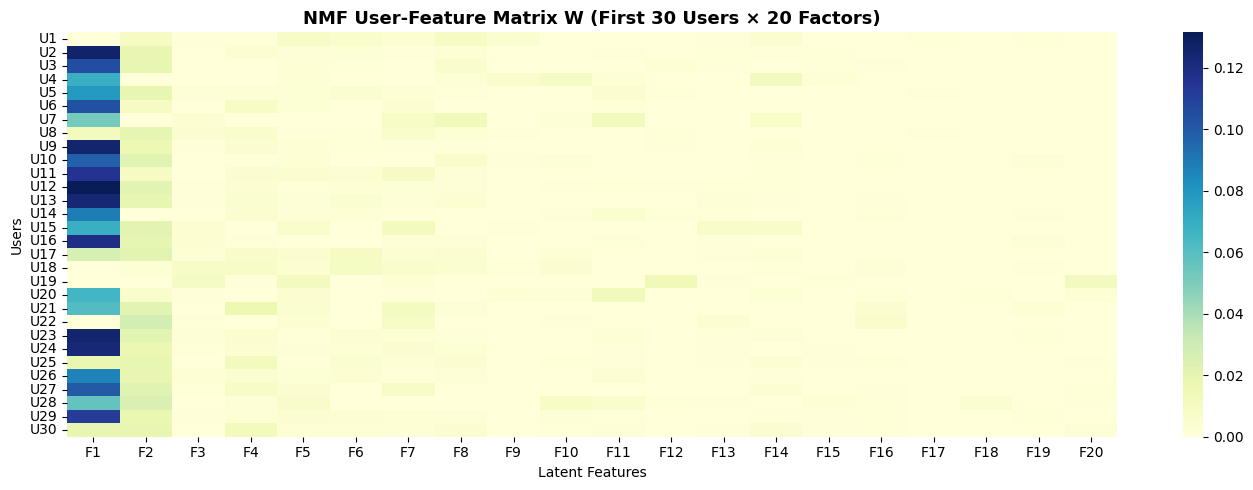

In [ ]:
# ── 5: Latent Feature Heatmap (NMF User-Feature Matrix W) ───────────────────
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(W[:30, :20], cmap='YlGnBu', ax=ax,
            xticklabels=[f'F{i+1}' for i in range(20)],
            yticklabels=[f'U{i+1}' for i in range(30)])
ax.set_title('NMF User-Feature Matrix W (First 30 Users × 20 Factors)', fontsize=13, fontweight='bold')
ax.set_xlabel('Latent Features')
ax.set_ylabel('Users')
plt.tight_layout()
plt.show()

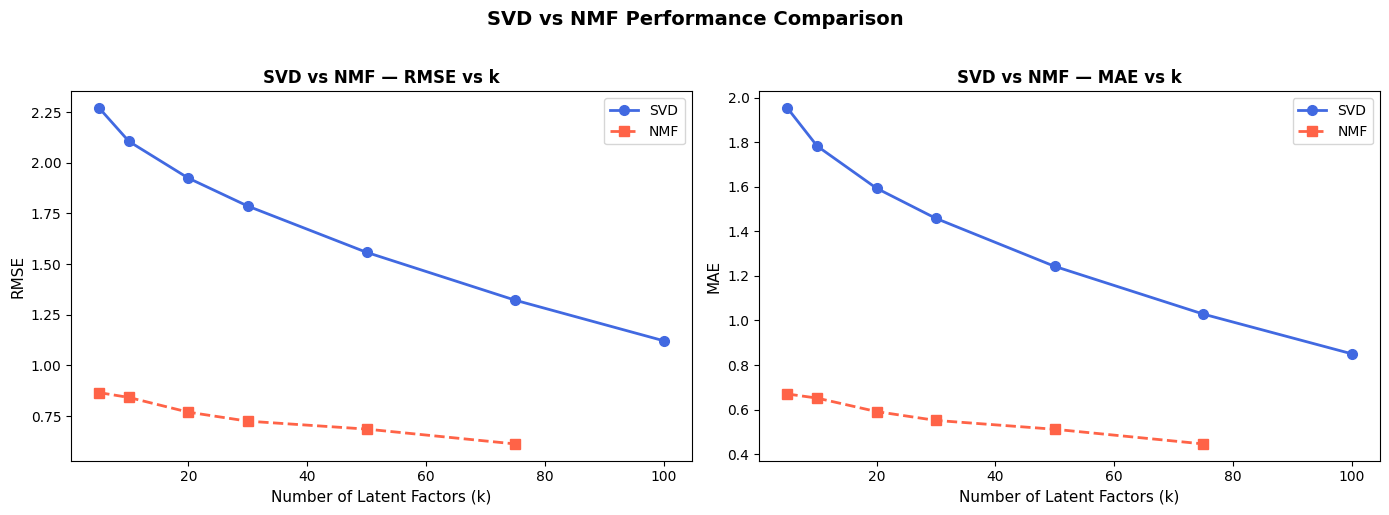

In [ ]:
# ── 6: SVD vs NMF RMSE across k ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE comparison
axes[0].plot(k_values, rmse_list, 'o-', label='SVD', color='royalblue', linewidth=2, markersize=7)
axes[0].plot(k_values_nmf, nmf_rmse_list, 's--', label='NMF', color='tomato', linewidth=2, markersize=7)
axes[0].set_xlabel('Number of Latent Factors (k)', fontsize=11)
axes[0].set_ylabel('RMSE', fontsize=11)
axes[0].set_title('SVD vs NMF — RMSE vs k', fontsize=12, fontweight='bold')
axes[0].legend()

# MAE comparison
axes[1].plot(k_values, mae_list, 'o-', label='SVD', color='royalblue', linewidth=2, markersize=7)
axes[1].plot(k_values_nmf, nmf_mae_list, 's--', label='NMF', color='tomato', linewidth=2, markersize=7)
axes[1].set_xlabel('Number of Latent Factors (k)', fontsize=11)
axes[1].set_ylabel('MAE', fontsize=11)
axes[1].set_title('SVD vs NMF — MAE vs k', fontsize=12, fontweight='bold')
axes[1].legend()

plt.suptitle('SVD vs NMF Performance Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

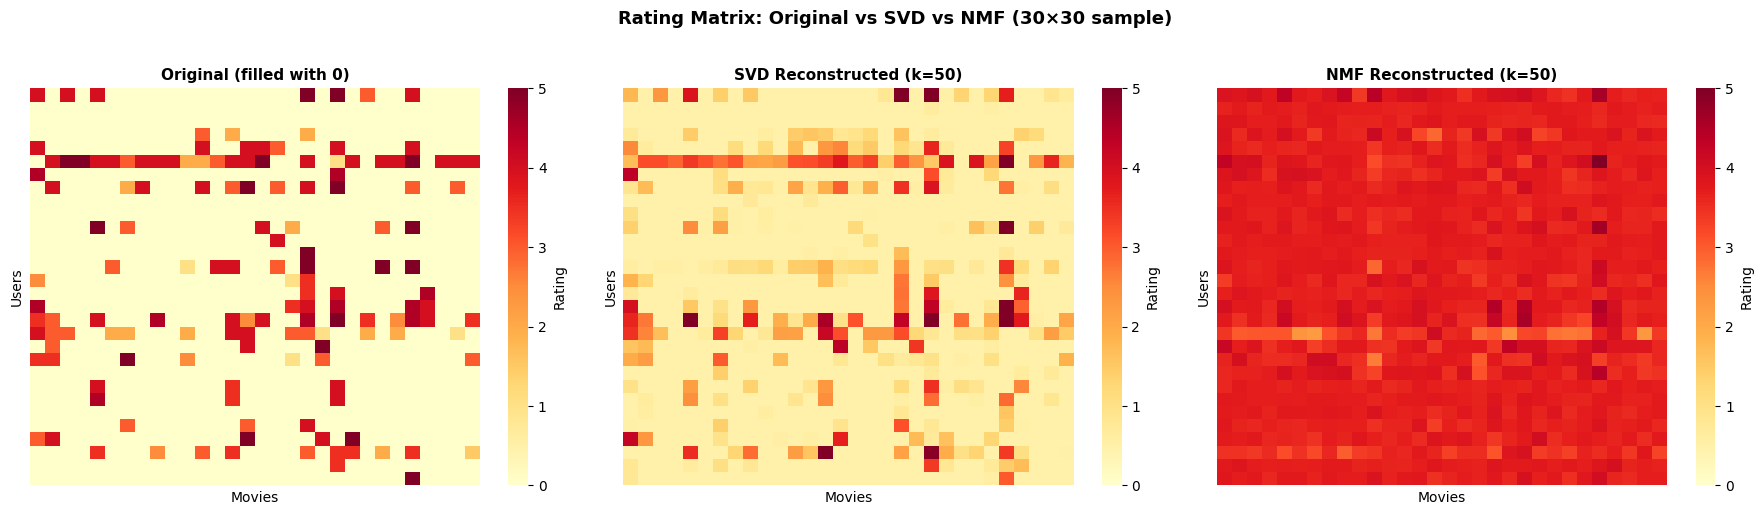

In [ ]:
# ── 7: Original vs SVD vs NMF Reconstruction Heatmap ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, data, title in zip(
    axes,
    [orig_sample, recon_sample, nmf_df.loc[sample_users, sample_movies]],
    ['Original (filled with 0)', 'SVD Reconstructed (k=50)', 'NMF Reconstructed (k=50)']
):
    sns.heatmap(data, ax=ax, cmap='YlOrRd', vmin=0, vmax=5,
                xticklabels=False, yticklabels=False, cbar_kws={'label': 'Rating'})
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Movies')
    ax.set_ylabel('Users')

plt.suptitle('Rating Matrix: Original vs SVD vs NMF (30×30 sample)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

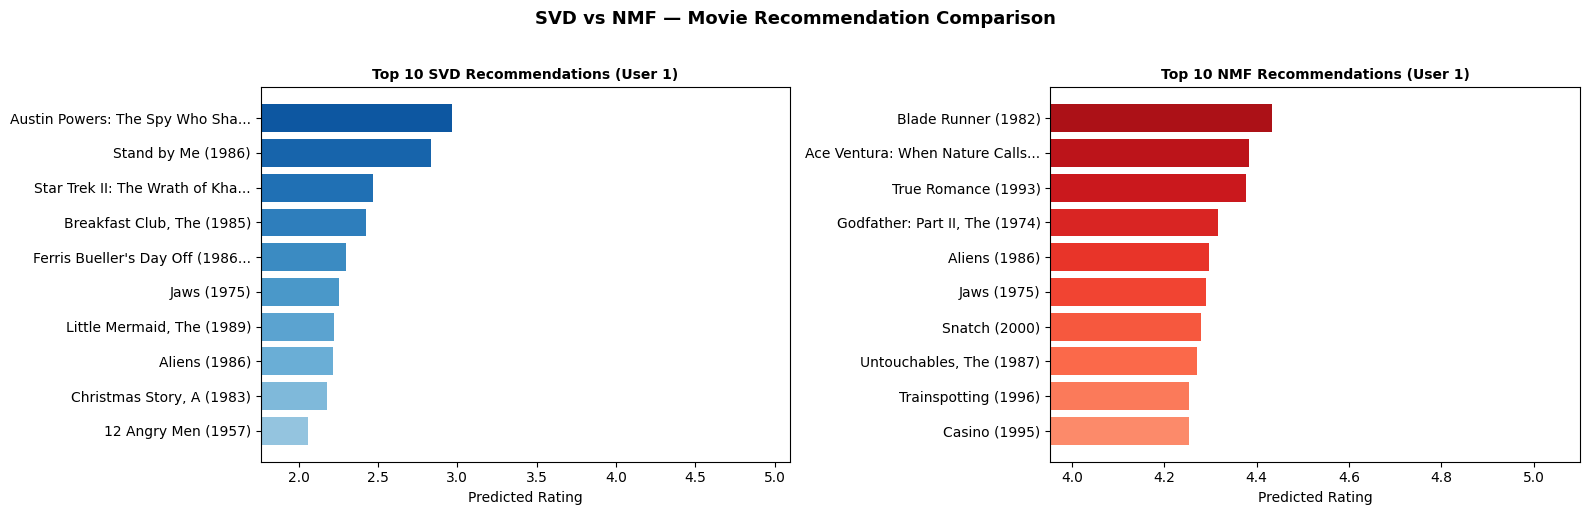

In [ ]:
# ── 8: Side-by-Side Recommendation Ranking Chart ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, recs, title, color in zip(
    axes,
    [recs_svd, recs_nmf],
    [f'Top 10 SVD Recommendations (User {sample_user})',
     f'Top 10 NMF Recommendations (User {sample_user})'],
    ['Blues', 'Reds']
):
    short_t = [t[:30] + '...' if len(t) > 30 else t for t in recs['title']]
    bar_colors = plt.get_cmap(color)(np.linspace(0.4, 0.85, 10))
    ax.barh(short_t[::-1], recs['predicted_rating'][::-1], color=bar_colors)
    ax.set_xlabel('Predicted Rating')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlim([min(recs['predicted_rating'])-0.3, 5.1])

plt.suptitle('SVD vs NMF — Movie Recommendation Comparison', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

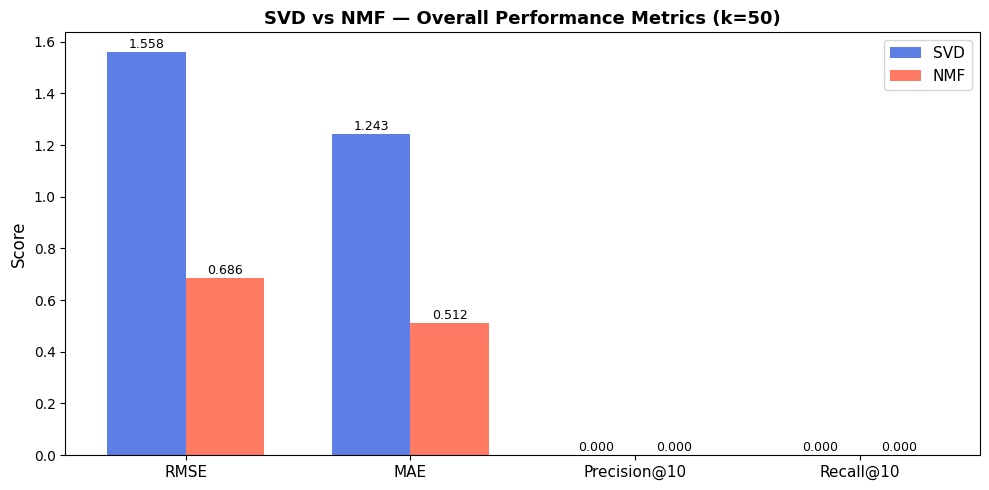

In [ ]:
# ── 9: Final Performance Summary Bar Chart ───────────────────────────────────
metrics = ['RMSE', 'MAE', 'Precision@10', 'Recall@10']
svd_scores = [rmse, mae, np.mean(prec_svd), np.mean(rec_svd)]
nmf_scores = [nmf_rmse, nmf_mae, np.mean(prec_nmf), np.mean(rec_nmf)]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, svd_scores, width, label='SVD', color='royalblue', alpha=0.85)
bars2 = ax.bar(x + width/2, nmf_scores, width, label='NMF', color='tomato', alpha=0.85)

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('SVD vs NMF — Overall Performance Metrics (k=50)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()